# Comprobación de regresiones
## Regresión lineal simple
### Ejemplo: Regresión lineal de precipitación contra mes en la estación 25001.

In [16]:
#Imports
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [17]:
df = pd.read_parquet('../data/processed/conAIgua_dataframe.parquet')
df_f = df[df['estacion_id'] == '25001'].dropna(subset=['mes', 'precip'])

In [18]:
x = df_f['mes'].values.reshape(-1, 1)
y = df_f['precip'].values

In [19]:
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

In [20]:
print(f"Intercepto:  {model.intercept_:.4f}")
print(f"Pendiente:   {model.coef_[0]:.4f}")
print(f"R2:          {r2_score(y, y_pred):.4f}")
print(f"RMSE:        {np.sqrt(mean_squared_error(y, y_pred)):.4f}")

Intercepto:  0.4102
Pendiente:   0.2820
R2:          0.0117
RMSE:        8.9626


In [21]:
# Intervalo de confianza
n = len(y)
residuals = y - y_pred
se = np.sqrt(np.sum(residuals**2) / (n - 2))
se_coef = se / np.sqrt(np.sum((x.flatten() - x.mean())**2))
t_critical = stats.t.ppf(0.975, df=n - 2)
margin = t_critical * se_coef
print(f"IC 95%:      ({model.coef_[0] - margin:.4f}, {model.coef_[0] + margin:.4f})")

IC 95%:      (0.2457, 0.3184)


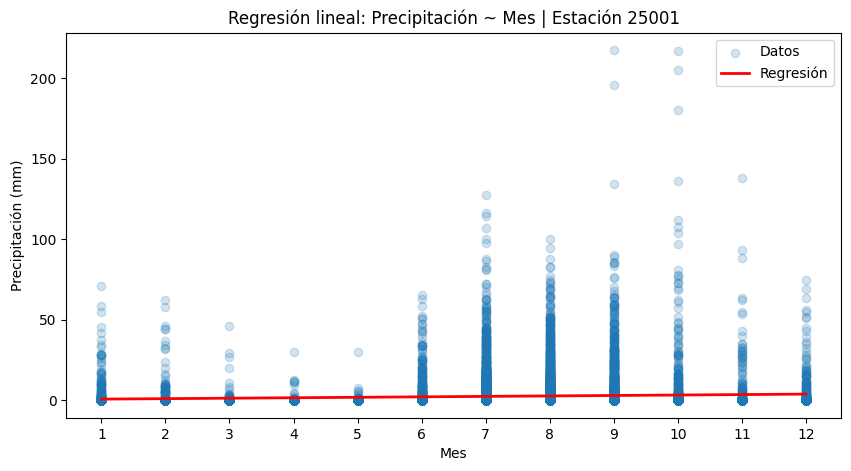

In [22]:
# Visualización
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(df_f['mes'], df_f['precip'], alpha=0.2, label='Datos')
x_line = np.arange(1, 13).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), color='red', linewidth=2, label='Regresión')
plt.xlabel('Mes')
plt.ylabel('Precipitación (mm)')
plt.title('Regresión lineal: Precipitación ~ Mes | Estación 25001')
plt.xticks(range(1, 13))
plt.legend()
plt.show()

## Regresión lineal múltiple 
### Ejemplo: Regresión múltiple de precipitación contra mes y año en la estación 25001.

In [23]:
df = pd.read_parquet('../data/processed/conAIgua_dataframe.parquet')
df_f = df[df['estacion_id'] == '25001'].dropna(subset=['mes', 'anio', 'precip'])

In [24]:
x = df_f[['mes', 'anio']].values
y = df_f['precip'].values
n = len(y)
p = 2

In [25]:
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

In [26]:
r2 = r2_score(y, y_pred)
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [27]:
print(f"Intercepto:    {model.intercept_:.4f}")
print(f"Coef mes:      {model.coef_[0]:.4f}")
print(f"Coef anio:     {model.coef_[1]:.4f}")
print(f"R2:            {r2:.4f}")
print(f"R2 ajustado:   {r2_adj:.4f}")
print(f"RMSE:          {np.sqrt(mean_squared_error(y, y_pred)):.4f}")

Intercepto:    -8.3825
Coef mes:      0.2824
Coef anio:     0.0044
R2:            0.0118
R2 ajustado:   0.0117
RMSE:          8.9623
